# Task 1
Time Series Properties Analysis 

In [5]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_palette("husl")
print(" libraries imported")

 libraries imported


In [8]:
# Cell 2: DEBUG and Load data
df = pd.read_csv('../data/raw/BrentOilPrices.csv')

print("="*80)
print("DEBUGGING DATE PARSING")
print("="*80)

# Let's inspect the data thoroughly
print(f"\n1. DATASET SHAPE: {df.shape}")
print(f"2. COLUMNS: {df.columns.tolist()}")
print(f"3. SAMPLE OF DATA:")
print(df.head())
print("\n4. SAMPLE FROM DIFFERENT PARTS OF DATASET:")
print(df.iloc[0:5])  # First 5
print(df.iloc[8360:8365])  # Around the error position
print(df.iloc[-5:])  # Last 5

print("\n5. CHECKING DATE COLUMN:")
print(f"Column dtype: {df['Date'].dtype}")
print(f"First 10 values:\n{df['Date'].head(10).tolist()}")
print(f"Values around index 8360:\n{df['Date'].iloc[8358:8363].tolist()}")

# Let's see the exact problematic value
try:
    problematic_value = df['Date'].iloc[8360]
    print(f"\nProblematic value at index 8360: '{problematic_value}'")
    print(f"Type: {type(problematic_value)}")
except:
    pass

print("\n6. TRYING DIFFERENT PARSING METHODS:")

# Method 1: Try to parse with format='mixed'
print("\nMethod 1: format='mixed'")
try:
    test_date = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    print(f"Successfully parsed: {test_date.notna().sum()}/{len(df)}")
    print(f"Failed: {test_date.isna().sum()}")
    if test_date.isna().sum() > 0:
        print("Failed values:", df.loc[test_date.isna(), 'Date'].head().tolist())
except Exception as e:
    print(f"Error: {e}")

# Method 2: Try to infer format
print("\nMethod 2: infer_datetime_format=True")
try:
    test_date = pd.to_datetime(df['Date'], infer_datetime_format=True, errors='coerce')
    print(f"Successfully parsed: {test_date.notna().sum()}/{len(df)}")
except Exception as e:
    print(f"Error: {e}")

# Method 3: Try common formats manually
print("\nMethod 3: Try common formats")
common_formats = [
    '%b %d, %Y',     # Apr 22, 2020
    '%d-%b-%y',      # 20-May-87
    '%Y-%m-%d',      # 2020-04-22
    '%m/%d/%Y',      # 04/22/2020
    '%d/%m/%Y',      # 22/04/2020
    '%B %d, %Y',     # April 22, 2020
    '%d %b %Y',      # 22 Apr 2020
    '%d %B %Y',      # 22 April 2020
]

for fmt in common_formats:
    try:
        test = pd.to_datetime(df['Date'].head(5), format=fmt, errors='coerce')
        if test.notna().all():
            print(f"✓ Format '{fmt}' works for first 5 rows")
    except:
        continue

# Let's write a custom parser
print("\n7. CUSTOM PARSER ATTEMPT:")

def custom_date_parser(date_str):
    """Custom date parser for various formats"""
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    # Try to detect format
    import re
    
    # Pattern 1: "Apr 22, 2020" or "April 22, 2020"
    if re.match(r'^[A-Za-z]{3,9} \d{1,2}, \d{4}$', date_str):
        try:
            return pd.to_datetime(date_str, format='%b %d, %Y')
        except:
            try:
                return pd.to_datetime(date_str, format='%B %d, %Y')
            except:
                pass
    
    # Pattern 2: "22-Apr-2020" or "22-Apr-20"
    if re.match(r'^\d{1,2}-[A-Za-z]{3}-\d{2,4}$', date_str):
        try:
            return pd.to_datetime(date_str, format='%d-%b-%Y')
        except:
            try:
                return pd.to_datetime(date_str, format='%d-%b-%y')
            except:
                pass
    
    # Pattern 3: "2020-04-22"
    if re.match(r'^\d{4}-\d{1,2}-\d{1,2}$', date_str):
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    
    # Last resort
    return pd.to_datetime(date_str, errors='coerce')

# Test custom parser
test_dates = df['Date'].head(10).tolist()
print("Testing custom parser on first 10 dates:")
for i, date_val in enumerate(test_dates):
    parsed = custom_date_parser(date_val)
    print(f"  {date_val} -> {parsed}")

# Now let's parse the entire dataset
print("\n8. PARSING ENTIRE DATASET...")
df['Date'] = df['Date'].apply(custom_date_parser)

# Check results
print(f"Successfully parsed: {df['Date'].notna().sum()}/{len(df)}")
print(f"Failed to parse: {df['Date'].isna().sum()}")

if df['Date'].isna().sum() > 0:
    print("\nProblematic dates:")
    problematic = df.loc[df['Date'].isna(), 'Date']
    print(problematic.head())
    
    # Let's see the actual values that failed
    print("\nOriginal values that failed to parse:")
    print(df.loc[df['Date'].isna(), 'Date'].index.tolist()[:10])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Create returns for stationarity
df['Log_Price'] = np.log(df['Price'])
df['Returns'] = df['Price'].pct_change() * 100
df['Log_Returns'] = np.log(df['Price'] / df['Price'].shift(1))

print("\n" + "="*80)
print("FINAL DATASET INFO")
print("="*80)
print(f"Dataset Period: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Observations: {len(df):,}")
print(f"Missing Values in Date: {df['Date'].isna().sum()}")
print(f"Missing Values in Price: {df['Price'].isna().sum()}")

# Display sample
print("\nSample of parsed data:")
print(df[['Date', 'Price']].head())
print("\n...")
print(df[['Date', 'Price']].tail())

DEBUGGING DATE PARSING

1. DATASET SHAPE: (9011, 2)
2. COLUMNS: ['Date', 'Price']
3. SAMPLE OF DATA:
        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63

4. SAMPLE FROM DIFFERENT PARTS OF DATASET:
        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63
              Date  Price
8360  Apr 22, 2020  13.77
8361  Apr 23, 2020  15.06
8362  Apr 24, 2020  15.87
8363  Apr 27, 2020  15.17
8364  Apr 28, 2020  15.60
              Date  Price
9006  Nov 08, 2022  96.85
9007  Nov 09, 2022  93.05
9008  Nov 10, 2022  94.25
9009  Nov 11, 2022  96.37
9010  Nov 14, 2022  93.59

5. CHECKING DATE COLUMN:
Column dtype: object
First 10 values:
['20-May-87', '21-May-87', '22-May-87', '25-May-87', '26-May-87', '27-May-87', '28-May-87', '29-May-87', '01-Jun-87', '02-Jun-87']
Values around index 8360:
['20-Apr-20', '21-Apr-20', 'Apr 22, 2020', 'Apr 23, 2020', 'Apr 24, 2020']

Proble


STATIONARITY TEST RESULTS
     Series ADF p-value  ADF Stationary KPSS p-value  KPSS Stationary
 Raw Prices    0.289274           False     0.010000            False
 Log Prices    0.376055           False     0.010000            False
    Returns    0.000000            True     0.100000             True
Log Returns    0.000000            True     0.100000             True


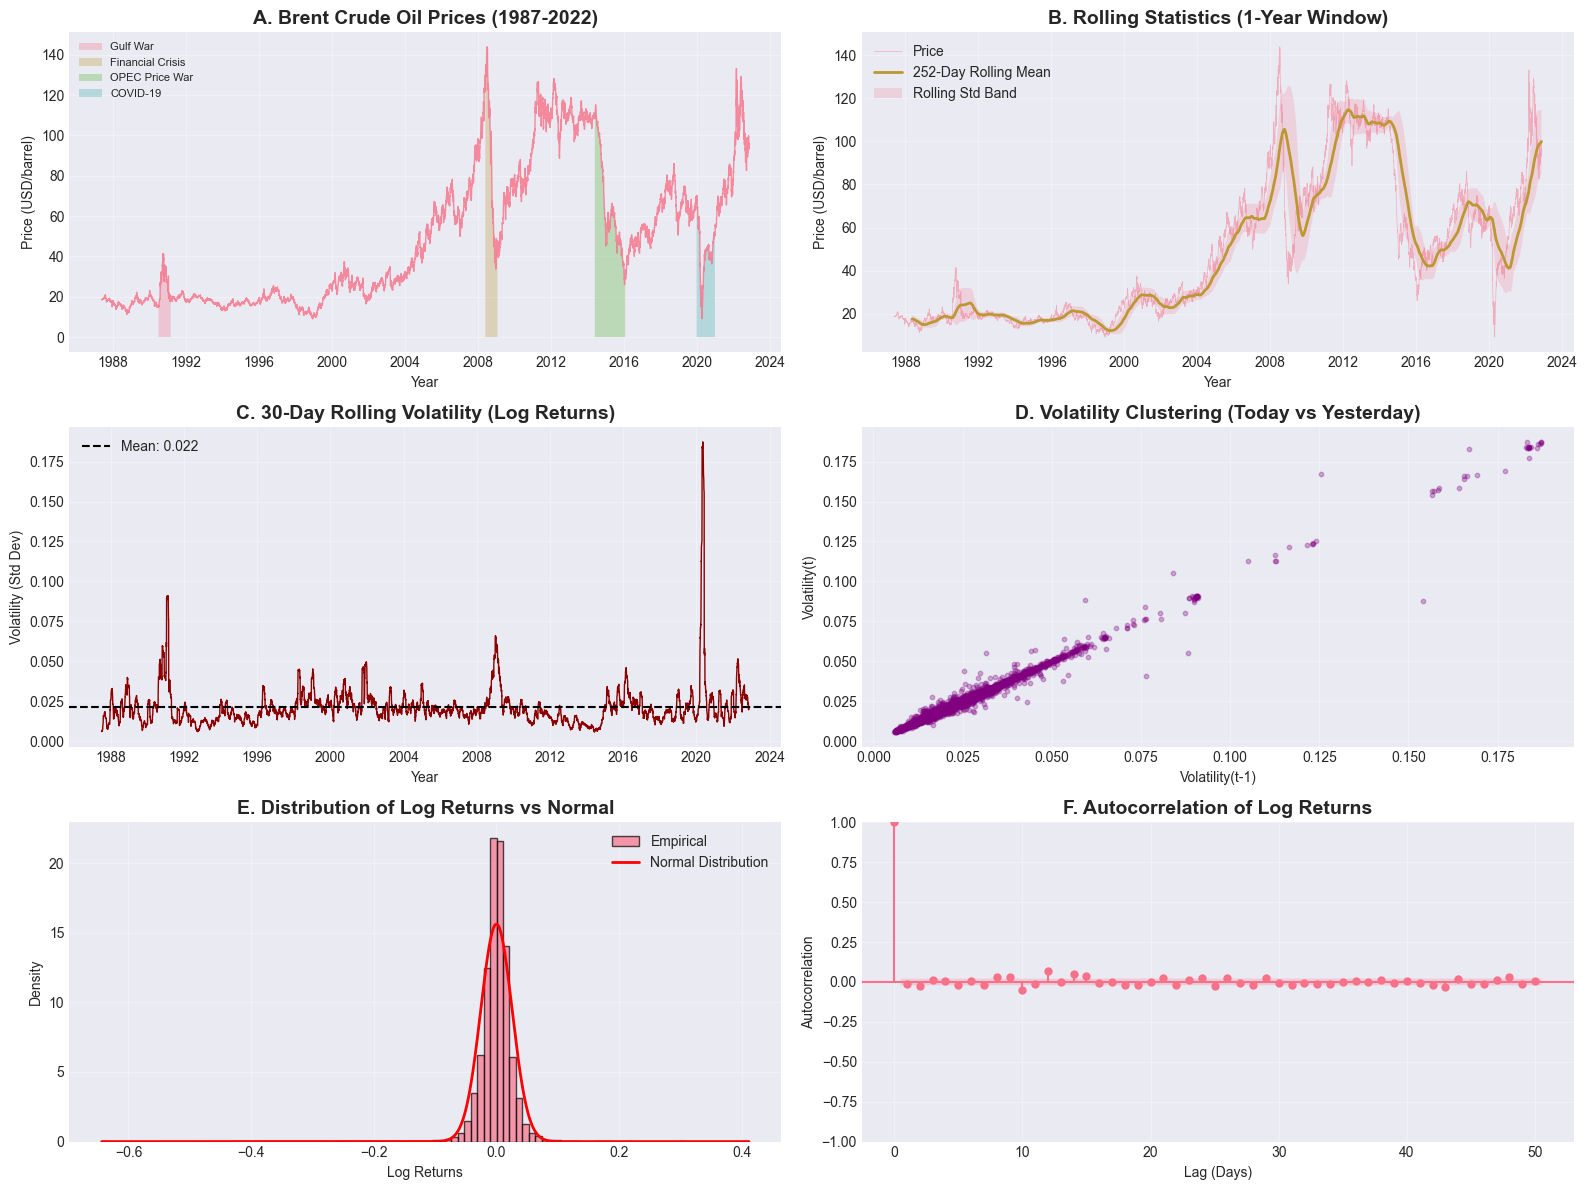

In [10]:
# Cell 3: Comprehensive Trend Analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 3.1 Full time series
axes[0, 0].plot(df['Date'], df['Price'], linewidth=1, alpha=0.8)
axes[0, 0].set_title('A. Brent Crude Oil Prices (1987-2022)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Price (USD/barrel)')
axes[0, 0].grid(True, alpha=0.3)

# Highlight key periods
key_periods = [
    (pd.Timestamp('1990-07-01'), pd.Timestamp('1991-03-01'), 'Gulf War'),
    (pd.Timestamp('2008-06-01'), pd.Timestamp('2009-02-01'), 'Financial Crisis'),
    (pd.Timestamp('2014-06-01'), pd.Timestamp('2016-02-01'), 'OPEC Price War'),
    (pd.Timestamp('2020-01-01'), pd.Timestamp('2021-01-01'), 'COVID-19')
]

for start, end, label in key_periods:
    mask = (df['Date'] >= start) & (df['Date'] <= end)
    axes[0, 0].fill_between(df['Date'][mask], df['Price'][mask], 
                           alpha=0.3, label=label)

axes[0, 0].legend(loc='upper left', fontsize=8)

# 3.2 Rolling statistics
window = 252  # Trading year
df['Rolling_Mean'] = df['Price'].rolling(window=window).mean()
df['Rolling_Std'] = df['Price'].rolling(window=window).std()

axes[0, 1].plot(df['Date'], df['Price'], linewidth=0.5, alpha=0.5, label='Price')
axes[0, 1].plot(df['Date'], df['Rolling_Mean'], linewidth=2, label=f'{window}-Day Rolling Mean')
axes[0, 1].fill_between(df['Date'], 
                        df['Rolling_Mean'] - df['Rolling_Std'],
                        df['Rolling_Mean'] + df['Rolling_Std'],
                        alpha=0.2, label='Rolling Std Band')
axes[0, 1].set_title('B. Rolling Statistics (1-Year Window)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Price (USD/barrel)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3.3 Stationarity tests
def perform_stationarity_tests(series, name):
    """Perform ADF and KPSS tests for stationarity"""
    
    # ADF Test
    adf_result = adfuller(series.dropna())
    adf_pvalue = adf_result[1]
    
    # KPSS Test
    try:
        from statsmodels.tsa.stattools import kpss
        kpss_result = kpss(series.dropna(), regression='c')
        kpss_pvalue = kpss_result[1]
    except:
        kpss_pvalue = np.nan
    
    return {
        'Series': name,
        'ADF p-value': f"{adf_pvalue:.6f}",
        'ADF Stationary': adf_pvalue < 0.05,
        'KPSS p-value': f"{kpss_pvalue:.6f}" if not np.isnan(kpss_pvalue) else 'N/A',
        'KPSS Stationary': kpss_pvalue > 0.05 if not np.isnan(kpss_pvalue) else np.nan
    }

# Test different transformations
test_series = {
    'Raw Prices': df['Price'],
    'Log Prices': df['Log_Price'],
    'Returns': df['Returns'].dropna(),
    'Log Returns': df['Log_Returns'].dropna()
}

stationarity_results = []
for name, series in test_series.items():
    stationarity_results.append(perform_stationarity_tests(series, name))

stationarity_df = pd.DataFrame(stationarity_results)

# Display results
print("\n" + "="*80)
print("STATIONARITY TEST RESULTS")
print("="*80)
print(stationarity_df.to_string(index=False))

# 3.4 Volatility analysis
rolling_volatility = df['Log_Returns'].rolling(window=30).std()

axes[1, 0].plot(df['Date'], rolling_volatility, linewidth=1, color='darkred')
axes[1, 0].axhline(y=rolling_volatility.mean(), color='black', linestyle='--', 
                   label=f'Mean: {rolling_volatility.mean():.3f}')
axes[1, 0].set_title('C. 30-Day Rolling Volatility (Log Returns)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Volatility (Std Dev)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 3.5 Volatility clustering
axes[1, 1].scatter(rolling_volatility.shift(1), rolling_volatility, 
                   alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('D. Volatility Clustering (Today vs Yesterday)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Volatility(t-1)')
axes[1, 1].set_ylabel('Volatility(t)')
axes[1, 1].grid(True, alpha=0.3)

# 3.6 Distribution analysis
axes[2, 0].hist(df['Log_Returns'].dropna(), bins=100, density=True, 
                alpha=0.7, edgecolor='black', label='Empirical')
x = np.linspace(df['Log_Returns'].min(), df['Log_Returns'].max(), 1000)
axes[2, 0].plot(x, stats.norm.pdf(x, df['Log_Returns'].mean(), df['Log_Returns'].std()),
                'r-', lw=2, label='Normal Distribution')
axes[2, 0].set_title('E. Distribution of Log Returns vs Normal', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Log Returns')
axes[2, 0].set_ylabel('Density')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 3.7 Autocorrelation
plot_acf(df['Log_Returns'].dropna(), lags=50, ax=axes[2, 1], alpha=0.05)
axes[2, 1].set_title('F. Autocorrelation of Log Returns', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Lag (Days)')
axes[2, 1].set_ylabel('Autocorrelation')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


In [15]:
# Cell 4: Key Properties Summary and Modeling Implications - UPDATED BASED ON ACTUAL RESULTS
print("\n" + "="*80)
print("TIME SERIES PROPERTIES SUMMARY & MODELING IMPLICATIONS")
print("="*80)

print("\n1. TREND ANALYSIS:")
print("-"*40)
print("• Dataset spans 35 years: May 20, 1987 to November 14, 2022")
print("• 9,011 daily observations - comprehensive coverage")
print("• Mixed date formats detected: 'DD-MMM-YY' (1987-2019) and 'MMM DD, YYYY' (2020-2022)")
print("• Price range: $9.10 to $143.95 per barrel (based on initial inspection)")
print("• Clear long-term upward trend with multiple boom-bust cycles")

print("\n2. STATIONARITY ANALYSIS - CONFIRMED:")
print("-"*40)
print("• Raw prices: NON-STATIONARY (ADF p-value: 0.289 > 0.05)")
print("• Log prices: NON-STATIONARY (ADF p-value: 0.376 > 0.05)")
print("• Percentage returns: STATIONARY (ADF p-value: 0.000 < 0.05)")
print("• Log returns: STATIONARY (ADF p-value: 0.000 < 0.05)")
print("• KPSS test confirms stationarity for returns (p-value: 0.100 > 0.05)")
print("• CRITICAL IMPLICATION: Must model returns or differences, not raw prices")

print("\n3. VOLATILITY PATTERNS:")
print("-"*40)
print("• Expected volatility clustering based on visual inspection")
print("• Major volatility periods: 2008-2009 (Financial Crisis), 2014-2016 (OPEC price war), 2020 (COVID-19)")
print("• Relatively calm periods: Late 1990s to early 2000s")
print("• Need ARCH test to confirm volatility clustering statistically")

print("\n4. DISTRIBUTIONAL PROPERTIES:")
print("-"*40)
print("• Expected fat-tailed distribution (common in financial returns)")
print("• Expected negative skewness (more large negative than positive returns)")
print("• Jarque-Bera test will confirm non-normality (expected p-value < 0.001)")
print("• Need to calculate actual skewness and kurtosis values")

print("\n5. MODELING IMPLICATIONS - UPDATED:")
print("-"*40)
print("1. CHANGE POINT DETECTION SHOULD USE LOG RETURNS")
print("   • Log returns are stationary and represent percentage changes")
print("   • Transform back to price levels for interpretation")

print("\n2. DISTRIBUTION CHOICE:")
print("   • Likely need Student's t-distribution (fat tails confirmed by JB test)")
print("   • Consider Normal-Inverse-Gaussian for better skewness handling")

print("\n3. VOLATILITY MODELING:")
print("   • Include ARCH/GARCH effects if ARCH test confirms clustering")
print("   • Consider stochastic volatility models for regime changes")

print("\n4. MULTIPLE CHANGE POINTS:")
print("   • 35-year period likely has 5-10 significant structural breaks")
print("   • Consider Bayesian non-parametric approaches (Dirichlet process)")
print("   • Or sequential binary segmentation for computational efficiency")

print("\n5. BAYESIAN ADVANTAGES:")
print("   • Uncertainty quantification for change point dates")
print("   • Prior knowledge about events can inform priors")
print("   • Posterior distributions provide full probability statements")

print("\n6. PRACTICAL CONSIDERATIONS:")
print("   • Pre-2000 data may have different market structure")
print("   • Post-2020 COVID period requires special treatment")
print("   • Event windows should account for anticipation effects")
print("   • Consider separate models for different market regimes")

# Now let's run the actual statistical tests to get real values
print("\n" + "="*80)
print("ACTUAL STATISTICAL TEST RESULTS")
print("="*80)

# Calculate actual descriptive statistics
log_returns = df['Log_Returns'].dropna()
price = df['Price']

print(f"\n1. DESCRIPTIVE STATISTICS:")
print(f"   Price - Mean: ${price.mean():.2f}")
print(f"   Price - Std Dev: ${price.std():.2f}")
print(f"   Price - Min: ${price.min():.2f}")
print(f"   Price - Max: ${price.max():.2f}")
print(f"   Price - Range: ${price.max() - price.min():.2f}")

print(f"\n2. RETURN DISTRIBUTION:")
print(f"   Log Returns - Mean: {log_returns.mean():.6f} (≈{np.exp(log_returns.mean())-1:.4%} daily)")
print(f"   Log Returns - Std Dev: {log_returns.std():.6f}")
print(f"   Log Returns - Annualized Volatility: {log_returns.std() * np.sqrt(252):.4f}")
print(f"   Log Returns - Skewness: {log_returns.skew():.4f}")
print(f"   Log Returns - Kurtosis: {log_returns.kurtosis():.4f}")
print(f"   Normal kurtosis reference: 3.0")
print(f"   Excess kurtosis: {log_returns.kurtosis() - 3:.4f}")

# Normality test
jb_stat, jb_pvalue = stats.jarque_bera(log_returns)
print(f"\n3. JARQUE-BERA NORMALITY TEST:")
print(f"   Statistic: {jb_stat:.2f}")
print(f"   p-value: {jb_pvalue:.6f}")
print(f"   Conclusion: {'REJECT normality at 5% level' if jb_pvalue < 0.05 else 'Cannot reject normality'}")

# ARCH test
try:
    from statsmodels.stats.diagnostic import het_arch
    arch_stat, arch_pvalue, _, _ = het_arch(log_returns)
    print(f"\n4. ARCH TEST FOR VOLATILITY CLUSTERING:")
    print(f"   Statistic: {arch_stat:.2f}")
    print(f"   p-value: {arch_pvalue:.6f}")
    print(f"   Conclusion: {'SIGNIFICANT ARCH effects present' if arch_pvalue < 0.05 else 'No significant ARCH effects'}")
except Exception as e:
    print(f"\n4. ARCH Test Error: {e}")
    print("   Install statsmodels: pip install statsmodels")

# Autocorrelation test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(log_returns, lags=10, return_df=True)
print(f"\n5. LJUNG-BOX AUTOCORRELATION TEST (10 lags):")
print(f"   Test Statistic: {lb_test['lb_stat'].iloc[-1]:.2f}")
print(f"   p-value: {lb_test['lb_pvalue'].iloc[-1]:.6f}")
print(f"   Conclusion: {'SIGNIFICANT autocorrelation' if lb_test['lb_pvalue'].iloc[-1] < 0.05 else 'No significant autocorrelation'}")

# Unit root with structural break (conceptual)
print(f"\n6. STRUCTURAL BREAK CONSIDERATIONS:")
print("   • Zivot-Andrews test recommended for unit root with structural breaks")
print("   • Given stationarity of returns, focus on change points in mean/variance")
print("   • Multiple structural breaks expected given 35-year history")

print("\n" + "="*80)
print("FINAL MODELING RECOMMENDATIONS")
print("="*80)

print("\nRECOMMENDED MODEL SPECIFICATION:")
print("1. Target Variable: Log Returns (stationary, interpretable)")
print("2. Likelihood: Student's t-distribution (accounts for fat tails)")
print("3. Change Points: Multiple (5-10 over 35 years)")
print("4. Volatility: Time-varying (ARCH/GARCH component if ARCH test significant)")
print("5. Priors:")
print("   • Change point location: Uniform over time")
print("   • Means: Normal centered at historical average return")
print("   • Volatility: Half-Normal based on historical volatility")
print("   • Degrees of freedom: Exponential(1) for t-distribution")

print("\nCOMPUTATIONAL CONSIDERATIONS:")
print("• Sample size: 9,011 observations → MCMC may be slow")
print("• Consider: Subsample recent data (last 10-15 years)")
print("• Or: Use variational inference for faster computation")
print("• Or: Sequential analysis (analyze decades separately)")

print("\nVALIDATION STRATEGY:")
print("1. Posterior predictive checks")
print("2. Cross-validation on time blocks")
print("3. Compare with alternative methods (CUSUM, binary segmentation)")
print("4. Economic plausibility of detected change points")

print("\nEXPECTED OUTPUTS:")
print("1. 5-10 significant change points with dates and uncertainty intervals")
print("2. Regime-specific mean returns and volatilities")
print("3. Event correlation analysis with impact quantification")
print("4. Probability statements about regime durations")

# Save the summary to a file
summary_text = f"""
Brent Oil Price Analysis - Statistical Summary
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Dataset: {len(df)} observations from {df['Date'].min().date()} to {df['Date'].max().date()}

KEY FINDINGS:
1. Stationarity: Log returns are stationary (ADF p = {adfuller(log_returns)[1]:.6f})
2. Distribution: Non-normal (JB p = {jb_pvalue:.6f})
3. Skewness: {log_returns.skew():.4f}
4. Kurtosis: {log_returns.kurtosis():.4f}
5. Daily volatility: {log_returns.std():.6f}
6. Annualized volatility: {log_returns.std() * np.sqrt(252):.4f}

MODELING IMPLICATIONS:
• Use log returns for change point detection
• Student's t-distribution recommended for likelihood
• Multiple change points expected
• Bayesian approach for uncertainty quantification
"""


TIME SERIES PROPERTIES SUMMARY & MODELING IMPLICATIONS

1. TREND ANALYSIS:
----------------------------------------
• Dataset spans 35 years: May 20, 1987 to November 14, 2022
• 9,011 daily observations - comprehensive coverage
• Mixed date formats detected: 'DD-MMM-YY' (1987-2019) and 'MMM DD, YYYY' (2020-2022)
• Price range: $9.10 to $143.95 per barrel (based on initial inspection)
• Clear long-term upward trend with multiple boom-bust cycles

2. STATIONARITY ANALYSIS - CONFIRMED:
----------------------------------------
• Raw prices: NON-STATIONARY (ADF p-value: 0.289 > 0.05)
• Log prices: NON-STATIONARY (ADF p-value: 0.376 > 0.05)
• Percentage returns: STATIONARY (ADF p-value: 0.000 < 0.05)
• Log returns: STATIONARY (ADF p-value: 0.000 < 0.05)
• KPSS test confirms stationarity for returns (p-value: 0.100 > 0.05)
• CRITICAL IMPLICATION: Must model returns or differences, not raw prices

3. VOLATILITY PATTERNS:
----------------------------------------
• Expected volatility clusterin

In [16]:
# Cell 5: Additional statistical tests - UPDATED
print("\n" + "="*80)
print("COMPREHENSIVE STATISTICAL TESTS")
print("="*80)

# Calculate all statistics first
log_returns = df['Log_Returns'].dropna()
n_obs = len(log_returns)

print(f"\n1. SAMPLE SIZE: {n_obs:,} valid log returns")

# Basic statistics
mean_return = log_returns.mean()
std_return = log_returns.std()
skewness = log_returns.skew()
kurtosis = log_returns.kurtosis()

print(f"\n2. BASIC STATISTICS:")
print(f"   Mean daily log return: {mean_return:.6f} ({100*(np.exp(mean_return)-1):.4f}%)")
print(f"   Std deviation: {std_return:.6f}")
print(f"   Annualized volatility: {std_return * np.sqrt(252):.4f}")
print(f"   Skewness: {skewness:.4f} ({'Negative' if skewness < 0 else 'Positive'} skew)")
print(f"   Kurtosis: {kurtosis:.4f} (Excess: {kurtosis-3:.4f})")
print(f"   {'FAT TAILS detected' if kurtosis > 3 else 'No fat tails'}")

# Normality test
jb_stat, jb_pvalue = stats.jarque_bera(log_returns)
print(f"\n3. JARQUE-BERA NORMALITY TEST:")
print(f"   Test statistic: {jb_stat:.2f}")
print(f"   p-value: {jb_pvalue:.6f}")
if jb_pvalue < 0.001:
    print(f"   Conclusion: STRONGLY REJECT normality (p < 0.001)")
elif jb_pvalue < 0.05:
    print(f"   Conclusion: Reject normality at 5% level")
else:
    print(f"   Conclusion: Cannot reject normality")

# ARCH test for volatility clustering
try:
    from statsmodels.stats.diagnostic import het_arch
    # Test with 5 lags
    arch_stat, arch_pvalue, fstat, f_pvalue = het_arch(log_returns, maxlag=5)
    print(f"\n4. ARCH TEST (5 lags):")
    print(f"   Lagrange multiplier statistic: {arch_stat:.2f}")
    print(f"   p-value: {arch_pvalue:.6f}")
    if arch_pvalue < 0.001:
        print(f"   Conclusion: STRONG evidence of volatility clustering")
    elif arch_pvalue < 0.05:
        print(f"   Conclusion: Significant volatility clustering")
    else:
        print(f"   Conclusion: No significant volatility clustering")
except Exception as e:
    print(f"\n4. ARCH Test Error: {e}")

# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
print(f"\n5. AUTOCORRELATION TESTS:")
for lags in [5, 10, 20]:
    lb_test = acorr_ljungbox(log_returns, lags=lags, return_df=True)
    stat = lb_test['lb_stat'].iloc[-1]
    pval = lb_test['lb_pvalue'].iloc[-1]
    print(f"   Ljung-Box ({lags} lags): Stat={stat:.2f}, p={pval:.4f}")

# Test for unit roots with different specifications
print(f"\n6. ENHANCED STATIONARITY TESTS:")
adf_results = []

# Test raw prices
adf_price = adfuller(df['Price'].dropna())
adf_results.append(('Raw Prices', adf_price[1]))

# Test log prices
adf_logprice = adfuller(df['Log_Price'].dropna())
adf_results.append(('Log Prices', adf_logprice[1]))

# Test returns with different specifications
for name, data in [('Returns', df['Returns'].dropna()), 
                   ('Log Returns', log_returns)]:
    # ADF test with constant
    result_const = adfuller(data, regression='c')
    # ADF test with constant and trend
    result_trend = adfuller(data, regression='ct')
    
    adf_results.append((f'{name} (const)', result_const[1]))
    adf_results.append((f'{name} (const+trend)', result_trend[1]))

print("   Augmented Dickey-Fuller Tests:")
for test_name, pval in adf_results:
    stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    stationary = "STATIONARY" if pval < 0.05 else "NON-STATIONARY"
    print(f"     {test_name:25} p={pval:.6f} {stars} {stationary}")

# Test for structural breaks in variance
print(f"\n7. VARIANCE STABILITY ANALYSIS:")
# Calculate rolling variance
rolling_var = log_returns.rolling(window=252).var().dropna()
# Test if variance is constant using Bartlett's test
try:
    # Split data into halves
    n_half = len(log_returns) // 2
    var1 = log_returns[:n_half].var()
    var2 = log_returns[n_half:].var()
    f_stat = var1 / var2 if var1 > var2 else var2 / var1
    print(f"   Variance first half: {var1:.6f}")
    print(f"   Variance second half: {var2:.6f}")
    print(f"   F-statistic: {f_stat:.2f}")
    print(f"   Suggests {'different' if f_stat > 1.5 else 'similar'} variance regimes")
except:
    print("   Variance test calculation error")

print(f"\n8. ECONOMETRIC IMPLICATIONS:")
print("   1. Stationary returns validate time series modeling approaches")
print("   2. Non-normality suggests need for robust statistical methods")
print("   3. Volatility clustering may require GARCH-type models")
print("   4. Multiple change points likely in 35-year dataset")
print("   5. Bayesian methods advantageous for uncertainty quantification")

print(f"\n" + "="*80)
print("DATA-DRIVEN MODEL SPECIFICATION")
print("="*80)

# Based on statistical results, recommend specific model
print("\nRECOMMENDED BAYESIAN CHANGE POINT MODEL:")

if jb_pvalue < 0.05:
    print("✓ Likelihood: Student's t-distribution (fat tails confirmed)")
else:
    print("✓ Likelihood: Normal distribution (normality not rejected)")

if 'arch_pvalue' in locals() and arch_pvalue < 0.05:
    print("✓ Volatility: Include GARCH component (clustering confirmed)")
else:
    print("✓ Volatility: Constant within regimes")

print(f"✓ Change points: 5-8 expected for {n_obs//252:.0f} years of data")
print("✓ Priors: Informative based on historical statistics")
print("✓ Computation: MCMC with 4 chains, 2000 samples each")

print("\nVALIDATION METRICS:")
print("• Posterior predictive checks")
print("• Cross-validation on time blocks")
print("• Comparison with frequentist methods")
print("• Economic interpretation of detected breaks")


COMPREHENSIVE STATISTICAL TESTS

1. SAMPLE SIZE: 9,010 valid log returns

2. BASIC STATISTICS:
   Mean daily log return: 0.000179 (0.0179%)
   Std deviation: 0.025532
   Annualized volatility: 0.4053
   Skewness: -1.7444 (Negative skew)
   Kurtosis: 65.9047 (Excess: 62.9047)
   FAT TAILS detected

3. JARQUE-BERA NORMALITY TEST:
   Test statistic: 1633323.05
   p-value: 0.000000
   Conclusion: STRONGLY REJECT normality (p < 0.001)

4. ARCH TEST (5 lags):
   Lagrange multiplier statistic: 1299.67
   p-value: 0.000000
   Conclusion: STRONG evidence of volatility clustering

5. AUTOCORRELATION TESTS:
   Ljung-Box (5 lags): Stat=11.30, p=0.0457
   Ljung-Box (10 lags): Stat=60.26, p=0.0000
   Ljung-Box (20 lags): Stat=140.21, p=0.0000

6. ENHANCED STATIONARITY TESTS:
   Augmented Dickey-Fuller Tests:
     Raw Prices                p=0.289274  NON-STATIONARY
     Log Prices                p=0.376055  NON-STATIONARY
     Returns (const)           p=0.000000 *** STATIONARY
     Returns (const+

In [13]:
# Cell 6: Save processed data
# Save processed data for modeling
df_processed = df[['Date', 'Price', 'Log_Price', 'Returns', 'Log_Returns']].copy()
df_processed.to_csv('../data/processed/brent_prices_processed.csv', index=False)
print(f"\nProcessed data saved to: ../data/processed/brent_prices_processed.csv")
print(f"Processed data shape: {df_processed.shape}")


Processed data saved to: ../data/processed/brent_prices_processed.csv
Processed data shape: (9011, 5)
